## MOLECULAR DESCRIPTORS CALCULATION (3D) - Eg with RDKit

#### 1. Set-up:

In [164]:
## packages to install if required (remove hashtag and run):
#!pip install pysmiles
#!pip install descriptastorus
#!pip install rdkit


In [165]:
## import necessary libraries:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pysmiles import read_smiles

from descriptastorus.descriptors.DescriptorGenerator import MakeGenerator

from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem, PandasTools
from rdkit.ML.Descriptors import MoleculeDescriptors


In [166]:
## export dataframe with substances + SMILES:
smiles_df = pd.read_csv('data/contaminants.csv', delimiter = ";")
smiles_df.head(10)


,name,substance_type,CAS_nb,SMILES,detected
0,carbaryl,insecticide,63-25-2,CNC(=O)OC1=CC=CC2=CC=CC=C21,1
1,chlorpyrifos,insecticide,2921-88-2,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1
2,cypermethrine,insecticide,52315-07-8,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1
3,DDD(2-4),insecticide,72-54-8,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1
4,dicofol,insecticide,115-32-2,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1
5,dieldrin,insecticide,60-57-1,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1
6,isodrin,insecticide,465-73-6,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1
7,lindane,insecticide,8065-09-6,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1
8,methomyl,insecticide,16752-77-5,CC(=NOC(=O)NC)SC,1
9,tebufenozide,insecticide,112410-23-8,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1


In [167]:
## data cleaning:
print(f"Length of database with NAs: {len(smiles_df.SMILES)}")

if smiles_df.SMILES.isna().sum() > 0:
    smiles_cleaned = smiles_df.loc[smiles_df.SMILES.notna()].copy() ## remove NAs (cannot compute molecular descriptor if no SMILES structure present)
    print(f"Length of database without NAs (cleaned version): {len(smiles_cleaned.SMILES)}")
else:
    None

smiles_cleaned = smiles_cleaned.drop("CAS_nb", axis = 1).copy()


Length of database with NAs: 70
Length of database without NAs (cleaned version): 67


In [168]:
## extract list of molecules from their SMILES:
smiles_list = smiles_cleaned.SMILES

mol_list = []

for s in smiles_list:
    mol = Chem.MolFromSmiles(s)
    mol_list.append(mol)


,name,substance_type,SMILES,detected,molecule
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1,
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1,
2,cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1,
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1,
4,dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1,
...,...,...,...,...,...
63,tramadol,PPCP,CN(C)C[C@H]1CCCC[C@@]1(C2=CC(=CC=C2)OC)O,0,
64,chloroacetic acid,solvent,C(C(=O)O)Cl,0,
65,DMSO,solvent,CS(=O)C,0,
66,methanol,solvent,CO,0,

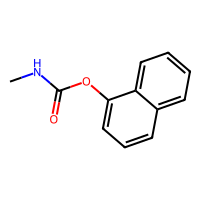
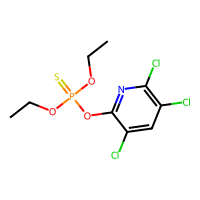
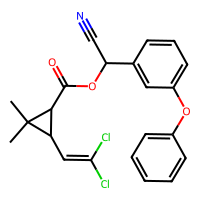
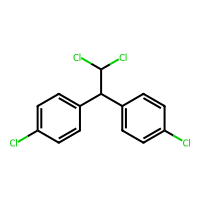
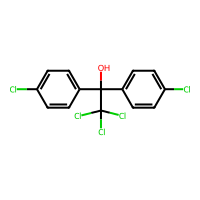
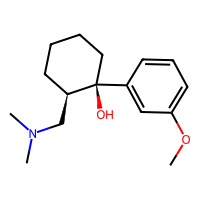
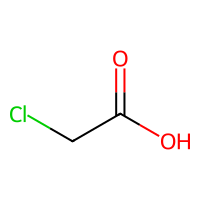
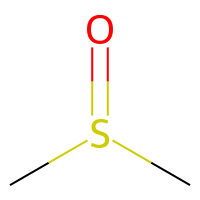
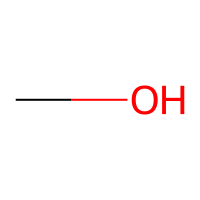
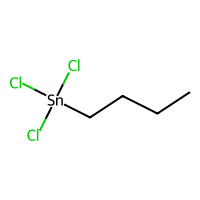

In [169]:
## add molecule column to df:
PandasTools.AddMoleculeColumnToFrame(smiles_cleaned, "SMILES", "molecule", includeFingerprints = True)
smiles_cleaned.molecule = mol_list
smiles_cleaned


#### 2. Basic chemical analysis of database:

In [170]:
## visualise 2D rep of substances from their SMILES (just to see, for fun):
pic = Draw.MolsToGridImage(mol_list, molsPerRow = 4, maxMols = 70, subImgSize = (200, 200), legends = list(smiles_cleaned.name), returnPNG = False)
#pic


In [171]:
## save molecular visualisation of present substances:
pic.save("plots/2d_rep_mols.png")


#### 3. Calculation of molecular descriptors:

In [172]:
Desc_list_func = MoleculeDescriptors.MolecularDescriptorCalculator(x[0] for x in Descriptors._descList)
names = Desc_list_func.GetDescriptorNames()


In [173]:
des = []

for mol in smiles_cleaned["molecule"]:
  des.append(Desc_list_func.CalcDescriptors(mol))

rdkit_df = pd.concat([smiles_cleaned.reset_index(drop = True), pd.DataFrame(des).reset_index(drop = True)], axis = 1)
rdkit_df


,name,substance_type,SMILES,detected,molecule,0,1,2,3,4,...,207,208,209,210,211,212,213,214,215,216
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1,<rdkit.Chem.rdchem.Mol object at 0x15ebc4890>,11.091562,11.091562,0.452451,-0.452451,0.769567,...,0,0,0,0,0,0,0,0,0,0
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1,<rdkit.Chem.rdchem.Mol object at 0x15ebdcc10>,5.937656,5.937656,0.052130,-2.918479,0.548341,...,0,0,0,0,0,0,0,0,0,0
2,cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1,<rdkit.Chem.rdchem.Mol object at 0x15ebdca50>,12.611418,12.611418,0.113804,-1.028401,0.528047,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1,<rdkit.Chem.rdchem.Mol object at 0x15ebdc7b0>,6.091872,6.091872,0.094568,-0.534860,0.615021,...,0,0,0,0,0,0,0,0,0,0
4,dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1,<rdkit.Chem.rdchem.Mol object at 0x15ebdc270>,10.990246,10.990246,0.420576,-1.963632,0.682416,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,tramadol,PPCP,CN(C)C[C@H]1CCCC[C@@]1(C2=CC(=CC=C2)OC)O,0,<rdkit.Chem.rdchem.Mol object at 0x15ebde2d0>,11.188994,11.188994,0.294774,-0.711250,0.906176,...,0,0,0,0,0,0,0,0,0,0
63,chloroacetic acid,solvent,C(C(=O)O)Cl,0,<rdkit.Chem.rdchem.Mol object at 0x15ebde340>,9.236111,9.236111,0.305556,-0.979938,0.475060,...,0,0,0,0,0,0,0,0,0,0
64,DMSO,solvent,CS(=O)C,0,<rdkit.Chem.rdchem.Mol object at 0x15ebde3b0>,9.555556,9.555556,0.611111,-0.611111,0.398185,...,0,0,0,0,0,0,0,0,0,0
65,methanol,solvent,CO,0,<rdkit.Chem.rdchem.Mol object at 0x15ebde420>,7.000000,7.000000,1.000000,1.000000,0.385284,...,0,0,0,0,0,0,0,0,0,0


#### 4. Cleaning of MD db (check NAs, replace NAs, etc):

In [174]:
condition = rdkit_df.iloc[:, 6:223].isna().sum() ## set condition on NA nb threshold

nas_replace = condition[(condition > 0) & (condition <= 10)].index ## indexes of cols where there is less than 10 NAs
#nas_drop = condition[condition > 10].index

rdkit_df[nas_replace] = rdkit_df[nas_replace].fillna(0) ## replace NA values with 0
rdkit_df ## check db & how it looks like now


,name,substance_type,SMILES,detected,molecule,0,1,2,3,4,...,207,208,209,210,211,212,213,214,215,216
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1,<rdkit.Chem.rdchem.Mol object at 0x15ebc4890>,11.091562,11.091562,0.452451,-0.452451,0.769567,...,0,0,0,0,0,0,0,0,0,0
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1,<rdkit.Chem.rdchem.Mol object at 0x15ebdcc10>,5.937656,5.937656,0.052130,-2.918479,0.548341,...,0,0,0,0,0,0,0,0,0,0
2,cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1,<rdkit.Chem.rdchem.Mol object at 0x15ebdca50>,12.611418,12.611418,0.113804,-1.028401,0.528047,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1,<rdkit.Chem.rdchem.Mol object at 0x15ebdc7b0>,6.091872,6.091872,0.094568,-0.534860,0.615021,...,0,0,0,0,0,0,0,0,0,0
4,dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1,<rdkit.Chem.rdchem.Mol object at 0x15ebdc270>,10.990246,10.990246,0.420576,-1.963632,0.682416,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,tramadol,PPCP,CN(C)C[C@H]1CCCC[C@@]1(C2=CC(=CC=C2)OC)O,0,<rdkit.Chem.rdchem.Mol object at 0x15ebde2d0>,11.188994,11.188994,0.294774,-0.711250,0.906176,...,0,0,0,0,0,0,0,0,0,0
63,chloroacetic acid,solvent,C(C(=O)O)Cl,0,<rdkit.Chem.rdchem.Mol object at 0x15ebde340>,9.236111,9.236111,0.305556,-0.979938,0.475060,...,0,0,0,0,0,0,0,0,0,0
64,DMSO,solvent,CS(=O)C,0,<rdkit.Chem.rdchem.Mol object at 0x15ebde3b0>,9.555556,9.555556,0.611111,-0.611111,0.398185,...,0,0,0,0,0,0,0,0,0,0
65,methanol,solvent,CO,0,<rdkit.Chem.rdchem.Mol object at 0x15ebde420>,7.000000,7.000000,1.000000,1.000000,0.385284,...,0,0,0,0,0,0,0,0,0,0


In [175]:
## check if there's still NAs present or not
rdkit_df.all().isna().sum() ## 0

0

#### 5. Export results to .csv file:

In [176]:
rdkit_df.to_csv("data/rdkit_descriptors.csv", index = False)
